## Intuition:

K-Nearest Neighbors makes no assumptions about the underlying data distribution and doesn't "learn" a function in the traditional sense. Instead, it's **instance-based (lazy) learning**: it memorizes the entire training set, and at prediction time, it simply looks at the `k` closest training points to the new query point and:
- **Classification** → takes a majority vote among their labels
- **Regression** → averages (or weighted-averages) their target values

The core assumption is that similar inputs tend to have similar outputs — points near each other in feature space likely belong to the same class or have similar target values.

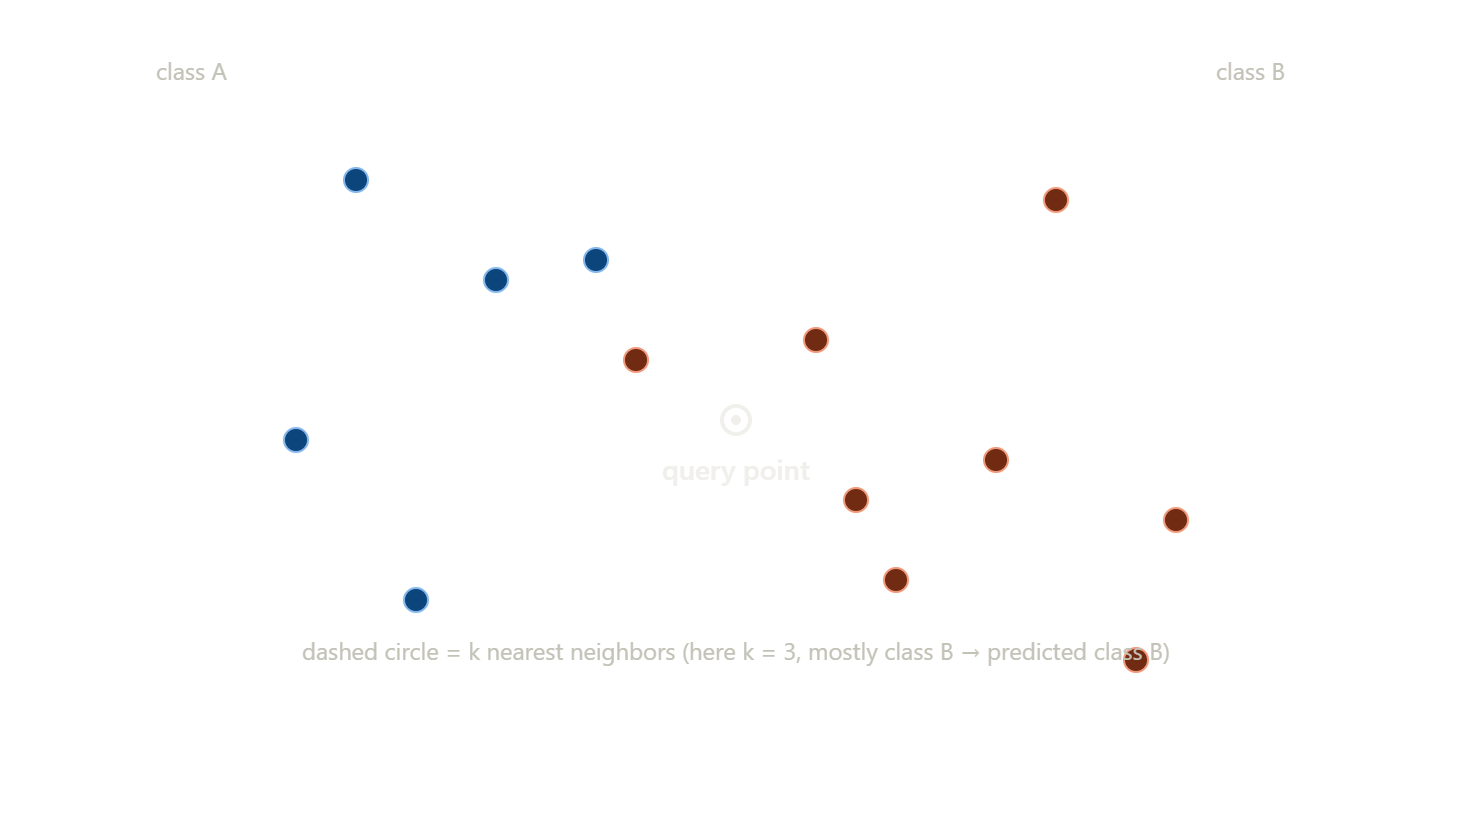

This diagram shows the whole idea in one picture: to classify the black query point, KNN looks at the k closest labeled points (inside the dashed circle) and takes a majority vote among them.

---

## Geometric Intuition:

"Closeness" is measured by distance in feature space — most commonly **Euclidean distance**, though Manhattan, Minkowski, or cosine distance are also used depending on the data. Every point in the training set can be thought of as sitting somewhere in an n-dimensional space (n = number of features). A prediction draws an implicit sphere (circle in 2D, as shown above) around the query point, expanding just far enough to capture `k` neighbors, then votes/averages among them.

**The value of `k` directly controls how "wiggly" or "smooth" that implicit decision boundary is** — this is the crux of the overfitting/underfitting behavior covered below.

---

## Types of KNN:

**By task:**
- **KNN Classifier** — majority vote among neighbors
- **KNN Regressor** — average (or distance-weighted average) of neighbors' values

**By voting scheme:**
- **Uniform (unweighted) KNN** — every one of the `k` neighbors counts equally
- **Distance-weighted KNN** — closer neighbors get more influence (typically weight ∝ 1/distance), so a very close point matters more than one at the edge of the neighborhood

**By distance metric:**
- **Euclidean** — straight-line distance, most common default
- **Manhattan** — sum of absolute coordinate differences, useful for grid-like or high-dimensional sparse data
- **Minkowski** — generalization of both (Euclidean is Minkowski with p=2, Manhattan with p=1)
- **Cosine similarity** — measures angle rather than magnitude, common in text/high-dimensional embedding spaces

**By search strategy (implementation detail, not a conceptual "type," but worth knowing):** brute-force search, KD-Tree, and Ball-Tree — these don't change the algorithm's output, just how efficiently the nearest neighbors are found.

---

## Overfitting and Underfitting — Both Governed by `k`:

- **Small `k` (e.g. k=1)** → **overfitting**. The decision boundary becomes extremely jagged, since each prediction depends on just one nearby point — a single noisy or mislabeled training point can flip a prediction. High variance, low bias.
- **Large `k` (e.g. k = entire dataset)** → **underfitting**. The neighborhood becomes so large that predictions start ignoring local structure entirely and converge toward the global majority class (or global average, for regression) — the boundary becomes overly smooth and loses discriminative power. High bias, low variance.
- **The right `k`** sits between these extremes and is typically found via cross-validation (e.g. testing accuracy across a range of `k` values, similar to the `n_components` search done earlier for PCA).

A useful rule of thumb: `k` is usually chosen as odd (for binary classification, to avoid ties) and scales loosely with dataset size — too small relative to the dataset and it's noise-sensitive, too large and it dilutes local structure.

---

## Failure Cases of KNN:

**1. Curse of dimensionality** — already directly relevant to material already covered. As feature count grows, distances between points become less meaningful (all points start appearing roughly equidistant), so "nearest" neighbors stop being genuinely close in any meaningful sense. This is one of the strongest motivations for pairing KNN with dimensionality reduction, exactly like the earlier PCA/LDA notebook did.

**2. Sensitive to feature scale** — since KNN relies entirely on distance, a feature with a larger numeric range (e.g. income in thousands vs. age in years) dominates the distance calculation unless features are scaled first (StandardScaler/MinMaxScaler) — this is why scaling was always applied before KNN in the earlier notebooks.

**3. Computationally expensive at prediction time** — there's no real "training" phase (it just stores the data), but every prediction requires searching the entire training set for neighbors, making inference slow on large datasets. This is exactly what showed up earlier when looping KNN across 784 PCA components — each fit was cheap, but prediction cost scaled with data size and dimensionality.

**4. Imbalanced classes bias predictions** — if one class vastly outnumbers others, it dominates the neighborhood vote by sheer density, even near the minority class's true region. Weighting by distance or resampling the data helps mitigate this.

**5. Poor performance with irrelevant/noisy features** — since every feature contributes to the distance calculation equally (unless weighted), irrelevant features add noise that drowns out the meaningful ones — another reason feature selection/extraction matters before applying KNN.

**6. Missing values and categorical data** — KNN needs a well-defined distance metric, so it doesn't natively handle missing values or unordered categorical variables without preprocessing (imputation, encoding).

---